<a href="https://colab.research.google.com/github/jyotipant614-cloud/AI_Resume_Analyser/blob/main/assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8: Global Pollution Analysis and Energy Recovery

## Objective

The objective of this project is to analyze global pollution and energy-related
data using Exploratory Data Analysis (EDA) and Apriori Association Rule Mining.

The analysis focuses on discovering relationships between:

- Air Pollution
- Water Pollution
- Soil Pollution
- Industrial Waste
- Energy Recovery
- CO2 Emissions
- Renewable Energy
- Energy Consumption

The discovered association rules are evaluated using:

- Support
- Confidence
- Lift

The project also validates the discovered rules using a train-test split and
5-fold cross-validation.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from collections import Counter

from sklearn.model_selection import train_test_split, KFold

import networkx as nx

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Global_Pollution_Analysis.csv to Global_Pollution_Analysis.csv


In [ ]:
file_name = "Global_Pollution_Analysis.csv"

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (200, 13)


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [ ]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

Columns:
['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Industrial_Waste (in tons)', 'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)', 'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)', 'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)', 'GDP_Per_Capita (in USD)']

Dataset Shape:
(200, 13)

Data Types:
Country                                    object
Year                                        int64
Air_Pollution_Index                       float64
Water_Pollution_Index                     float64
Soil_Pollution_Index                      float64
Industrial_Waste (in tons)                float64
Energy_Recovered (in GWh)                 float64
CO2_Emissions (in MT)                     float64
Renewable_Energy (%)                      float64
Plastic_Waste_Produced (in tons)          float64
Energy_Consumption_Per_Capita (in MWh)    float64
Population (in millions)                  float64
GDP_Per_Capita (in 

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values:
Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

Total Missing Values: 0


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.describe()

,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.00000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,2009.335000,180.62695,115.068100,76.488550,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,5.765325,67.07331,47.580911,39.692727,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,2000.000000,50.30000,31.130000,11.150000,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,2004.000000,134.97250,74.550000,40.895000,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,2010.000000,183.38500,112.305000,78.600000,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,2014.000000,237.42500,157.477500,109.212500,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,2019.000000,297.95000,199.320000,149.230000,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values with median
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

print("Data cleaning completed.")
print("Shape after cleaning:", df.shape)

Data cleaning completed.
Shape after cleaning: (200, 13)


In [ ]:
print("Missing values after cleaning:")
print(df.isnull().sum().sum())

print("\nDuplicate rows after cleaning:")
print(df.duplicated().sum())

Missing values after cleaning:
0

Duplicate rows after cleaning:
0


In [ ]:
pollution_columns = [
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index"
]

pollution_columns

['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']

In [ ]:
for col in pollution_columns:
    min_value = df[col].min()
    max_value = df[col].max()

    df[col + "_Normalized"] = (
        (df[col] - min_value) / (max_value - min_value)
    )

df[
    [
        "Air_Pollution_Index_Normalized",
        "Water_Pollution_Index_Normalized",
        "Soil_Pollution_Index_Normalized"
    ]
].head()

,Air_Pollution_Index_Normalized,Water_Pollution_Index_Normalized,Soil_Pollution_Index_Normalized
0,0.898042,0.553778,0.295481
1,0.147062,0.173673,0.768178
2,0.166727,0.310542,0.800768
3,0.929982,0.214222,0.596973
4,0.520331,0.573161,0.799537


In [ ]:
def pollution_level(value):
    if value < 0.33:
        return "Low"
    elif value < 0.66:
        return "Medium"
    else:
        return "High"


df["Air_Pollution_Level"] = df["Air_Pollution_Index_Normalized"].apply(
    pollution_level
)

df["Water_Pollution_Level"] = df["Water_Pollution_Index_Normalized"].apply(
    pollution_level
)

df["Soil_Pollution_Level"] = df["Soil_Pollution_Index_Normalized"].apply(
    pollution_level
)

df[
    [
        "Air_Pollution_Level",
        "Water_Pollution_Level",
        "Soil_Pollution_Level"
    ]
].head()

,Air_Pollution_Level,Water_Pollution_Level,Soil_Pollution_Level
0,High,Medium,Low
1,Low,Low,High
2,Low,Low,High
3,High,Low,Medium
4,Medium,Medium,High


In [ ]:
df["Energy_Consumption_Level"] = pd.qcut(
    df["Energy_Consumption_Per_Capita (in MWh)"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

df["Energy_Consumption_Level"].value_counts()

,count
Energy_Consumption_Level,
Low,67
High,67
Medium,66


In [ ]:
df["Energy_Recovery_Level"] = pd.qcut(
    df["Energy_Recovered (in GWh)"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

df["Energy_Recovery_Level"].value_counts()

,count
Energy_Recovery_Level,
Low,67
High,67
Medium,66


In [ ]:
df["Renewable_Energy_Level"] = pd.qcut(
    df["Renewable_Energy (%)"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

df["Renewable_Energy_Level"].value_counts()

,count
Renewable_Energy_Level,
Low,67
High,67
Medium,66


In [ ]:
df["CO2_Emission_Level"] = pd.qcut(
    df["CO2_Emissions (in MT)"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

df["CO2_Emission_Level"].value_counts()

,count
CO2_Emission_Level,
Low,67
High,67
Medium,66


In [ ]:
df = df.sort_values(["Country", "Year"]).reset_index(drop=True)

df["Air_Pollution_Trend"] = "No Previous Year"

for country in df["Country"].unique():

    country_index = df[df["Country"] == country].index

    previous_value = None

    for idx in country_index:

        current_value = df.loc[idx, "Air_Pollution_Index"]

        if previous_value is None:
            df.loc[idx, "Air_Pollution_Trend"] = "No Previous Year"
        elif current_value > previous_value:
            df.loc[idx, "Air_Pollution_Trend"] = "Increasing"
        elif current_value < previous_value:
            df.loc[idx, "Air_Pollution_Trend"] = "Decreasing"
        else:
            df.loc[idx, "Air_Pollution_Trend"] = "Stable"

        previous_value = current_value

df["Air_Pollution_Trend"].value_counts()

,count
Air_Pollution_Trend,
No Previous Year,175
Decreasing,15
Increasing,10


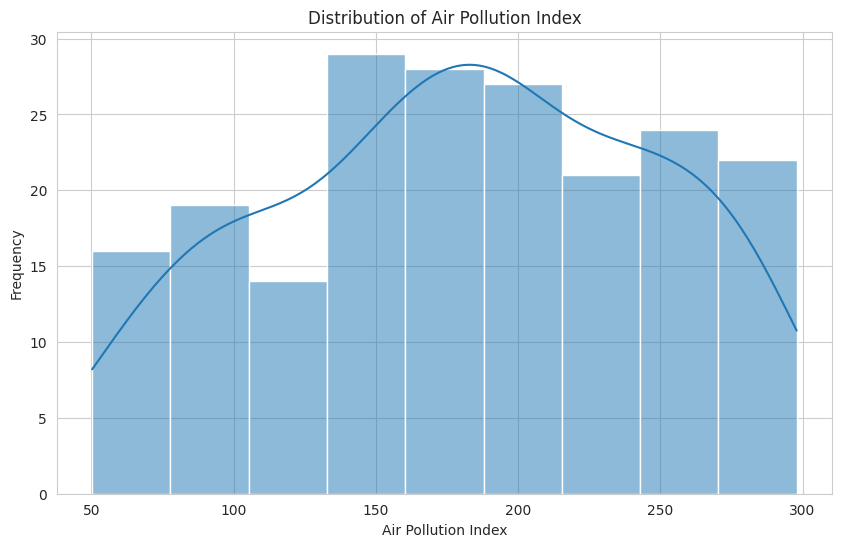

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Air_Pollution_Index"],
    kde=True
)

plt.title("Distribution of Air Pollution Index")
plt.xlabel("Air Pollution Index")
plt.ylabel("Frequency")

plt.show()

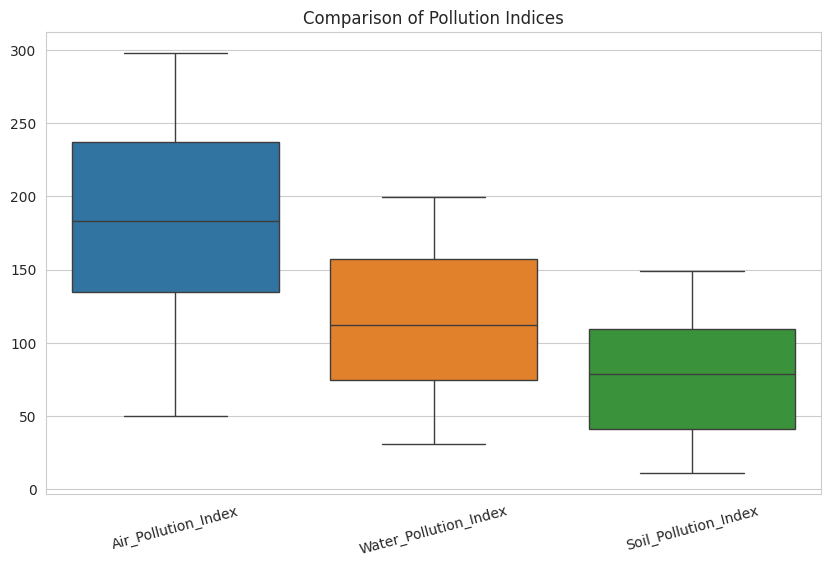

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df[pollution_columns]
)

plt.title("Comparison of Pollution Indices")
plt.xticks(rotation=15)

plt.show()

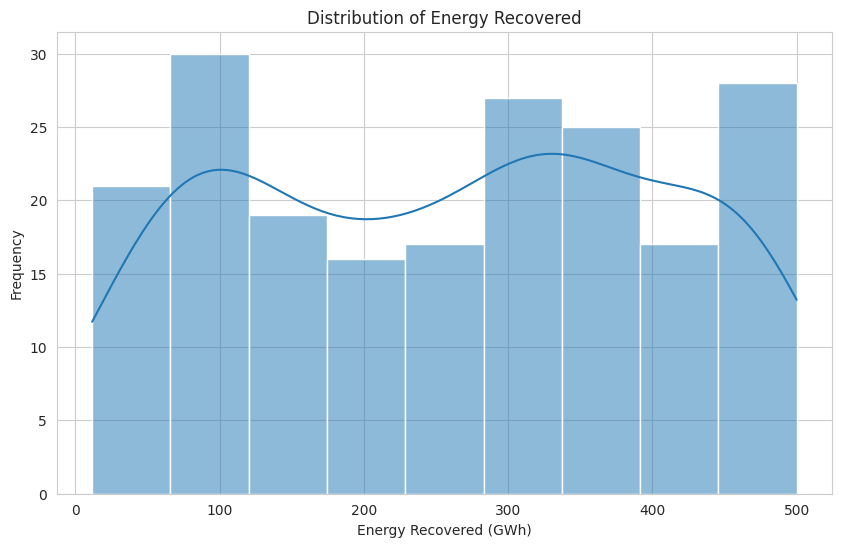

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Energy_Recovered (in GWh)"],
    kde=True
)

plt.title("Distribution of Energy Recovered")
plt.xlabel("Energy Recovered (GWh)")
plt.ylabel("Frequency")

plt.show()

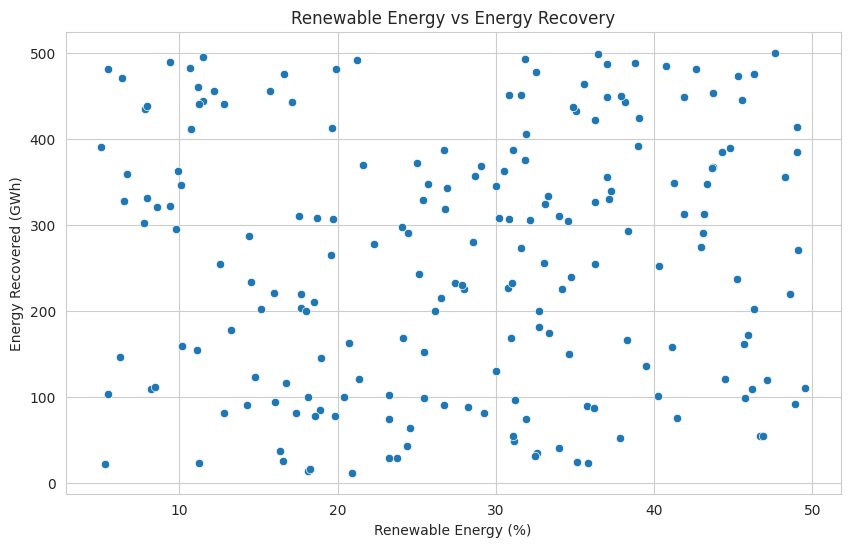

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Renewable_Energy (%)",
    y="Energy_Recovered (in GWh)"
)

plt.title("Renewable Energy vs Energy Recovery")
plt.xlabel("Renewable Energy (%)")
plt.ylabel("Energy Recovered (GWh)")

plt.show()

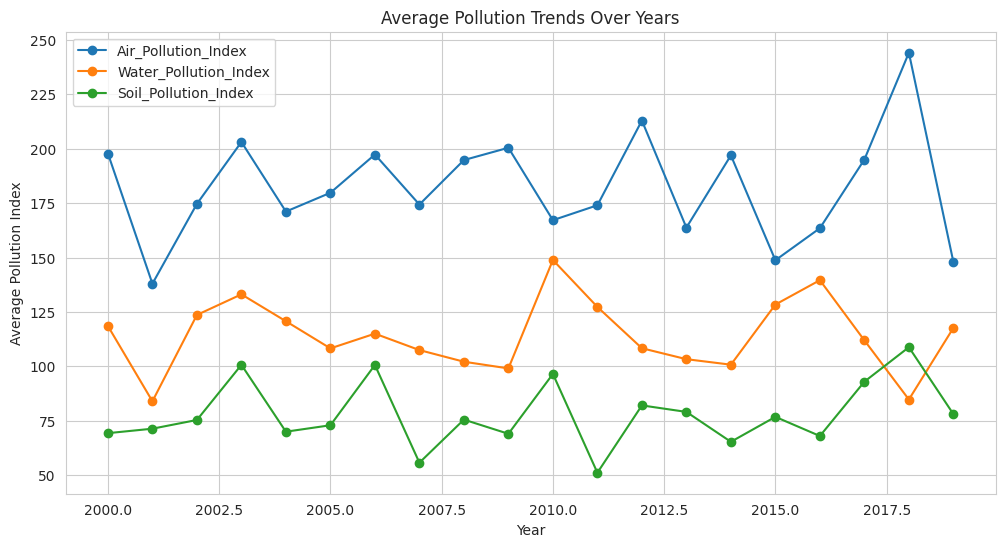

In [ ]:
yearly_pollution = df.groupby("Year")[
    pollution_columns
].mean()

plt.figure(figsize=(12, 6))

for column in pollution_columns:
    plt.plot(
        yearly_pollution.index,
        yearly_pollution[column],
        marker="o",
        label=column
    )

plt.title("Average Pollution Trends Over Years")
plt.xlabel("Year")
plt.ylabel("Average Pollution Index")
plt.legend()

plt.show()

In [ ]:
transaction_columns = [
    "Air_Pollution_Level",
    "Water_Pollution_Level",
    "Soil_Pollution_Level",
    "Energy_Consumption_Level",
    "Energy_Recovery_Level",
    "Renewable_Energy_Level",
    "CO2_Emission_Level"
]

transactions = []

for _, row in df.iterrows():

    transaction = set()

    for column in transaction_columns:

        value = row[column]

        if pd.notna(value):
            transaction.add(f"{column}={value}")

    transactions.append(transaction)

print("Number of transactions:", len(transactions))

print("\nExample transaction:")
print(transactions[0])

Number of transactions: 200

Example transaction:
{'Air_Pollution_Level=Medium', 'Energy_Consumption_Level=Medium', 'Renewable_Energy_Level=High', 'Water_Pollution_Level=Medium', 'Soil_Pollution_Level=Low', 'CO2_Emission_Level=Low', 'Energy_Recovery_Level=Low'}


In [ ]:
all_items = sorted(
    set().union(*transactions)
)

transaction_matrix = pd.DataFrame(
    0,
    index=range(len(transactions)),
    columns=all_items
)

for i, transaction in enumerate(transactions):

    for item in transaction:
        transaction_matrix.loc[i, item] = 1

print("Transaction matrix shape:", transaction_matrix.shape)

transaction_matrix.head()

Transaction matrix shape: (200, 21)


,Air_Pollution_Level=High,Air_Pollution_Level=Low,Air_Pollution_Level=Medium,CO2_Emission_Level=High,CO2_Emission_Level=Low,CO2_Emission_Level=Medium,Energy_Consumption_Level=High,Energy_Consumption_Level=Low,Energy_Consumption_Level=Medium,Energy_Recovery_Level=High,...,Energy_Recovery_Level=Medium,Renewable_Energy_Level=High,Renewable_Energy_Level=Low,Renewable_Energy_Level=Medium,Soil_Pollution_Level=High,Soil_Pollution_Level=Low,Soil_Pollution_Level=Medium,Water_Pollution_Level=High,Water_Pollution_Level=Low,Water_Pollution_Level=Medium
0,0,0,1,0,1,0,0,0,1,0,...,0,1,0,0,0,1,0,0,0,1
1,0,1,0,1,0,0,1,0,0,0,...,0,0,1,0,0,0,1,0,1,0
2,0,0,1,0,0,1,0,1,0,0,...,1,0,1,0,0,0,1,0,0,1
3,0,0,1,0,0,1,1,0,0,1,...,0,1,0,0,0,0,1,0,1,0
4,1,0,0,0,0,1,0,0,1,0,...,1,0,0,1,0,1,0,1,0,0


In [ ]:
def apriori(transaction_list, min_support=0.05):

    transaction_count = len(transaction_list)

    item_counts = Counter()

    for transaction in transaction_list:
        for item in transaction:
            item_counts[frozenset([item])] += 1

    frequent_itemsets = {}

    current_level = {}

    for itemset, count in item_counts.items():

        support = count / transaction_count

        if support >= min_support:
            current_level[itemset] = support

    frequent_itemsets.update(current_level)

    k = 2

    while current_level:

        previous_itemsets = list(current_level.keys())

        candidates = set()

        for i in range(len(previous_itemsets)):

            for j in range(i + 1, len(previous_itemsets)):

                union_set = previous_itemsets[i] | previous_itemsets[j]

                if len(union_set) == k:
                    candidates.add(union_set)

        candidate_counts = Counter()

        for transaction in transaction_list:

            for candidate in candidates:

                if candidate.issubset(transaction):
                    candidate_counts[candidate] += 1

        current_level = {}

        for itemset, count in candidate_counts.items():

            support = count / transaction_count

            if support >= min_support:
                current_level[itemset] = support

        frequent_itemsets.update(current_level)

        k += 1

    return frequent_itemsets

In [ ]:
MIN_SUPPORT = 0.05
MIN_CONFIDENCE = 0.40
MIN_LIFT = 1.0

print("Minimum Support:", MIN_SUPPORT)
print("Minimum Confidence:", MIN_CONFIDENCE)
print("Minimum Lift:", MIN_LIFT)

Minimum Support: 0.05
Minimum Confidence: 0.4
Minimum Lift: 1.0


In [ ]:
frequent_itemsets_dict = apriori(
    transactions,
    min_support=MIN_SUPPORT
)

print(
    "Number of frequent itemsets:",
    len(frequent_itemsets_dict)
)

Number of frequent itemsets: 404


In [ ]:
frequent_itemsets = pd.DataFrame(
    [
        {
            "itemset": ", ".join(sorted(itemset)),
            "support": support,
            "itemset_size": len(itemset)
        }
        for itemset, support in frequent_itemsets_dict.items()
    ]
)

frequent_itemsets = frequent_itemsets.sort_values(
    "support",
    ascending=False
).reset_index(drop=True)

frequent_itemsets.head(20)

,itemset,support,itemset_size
0,Air_Pollution_Level=Medium,0.405,1
1,Water_Pollution_Level=Medium,0.360,1
2,Soil_Pollution_Level=Low,0.355,1
3,Air_Pollution_Level=High,0.350,1
4,Soil_Pollution_Level=Medium,0.345,1
5,Energy_Recovery_Level=High,0.335,1
6,CO2_Emission_Level=High,0.335,1
7,Energy_Consumption_Level=High,0.335,1
8,Renewable_Energy_Level=Low,0.335,1
9,Energy_Consumption_Level=Low,0.335,1


In [ ]:
def generate_association_rules(
    frequent_itemsets_dict,
    min_confidence=0.40
):

    rules = []

    for itemset, itemset_support in frequent_itemsets_dict.items():

        if len(itemset) < 2:
            continue

        items = list(itemset)

        for r in range(1, len(items)):

            for antecedent_tuple in combinations(items, r):

                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                antecedent_support = frequent_itemsets_dict.get(
                    antecedent,
                    0
                )

                consequent_support = frequent_itemsets_dict.get(
                    consequent,
                    0
                )

                if antecedent_support == 0:
                    continue

                confidence = (
                    itemset_support /
                    antecedent_support
                )

                if consequent_support == 0:
                    continue

                lift = (
                    confidence /
                    consequent_support
                )

                if confidence >= min_confidence:

                    rules.append({
                        "antecedent": ", ".join(
                            sorted(antecedent)
                        ),
                        "consequent": ", ".join(
                            sorted(consequent)
                        ),
                        "support": itemset_support,
                        "confidence": confidence,
                        "lift": lift
                    })

    return pd.DataFrame(rules)

In [ ]:
rules = generate_association_rules(
    frequent_itemsets_dict,
    min_confidence=MIN_CONFIDENCE
)

print("Total rules generated:", len(rules))

rules.head()

Total rules generated: 519


,antecedent,consequent,support,confidence,lift
0,CO2_Emission_Level=Low,Water_Pollution_Level=Medium,0.160,0.477612,1.326700
1,Water_Pollution_Level=Medium,CO2_Emission_Level=Low,0.160,0.444444,1.326700
2,Energy_Recovery_Level=Low,Air_Pollution_Level=Medium,0.140,0.417910,1.031878
3,Energy_Recovery_Level=Low,Soil_Pollution_Level=Low,0.135,0.402985,1.135169
4,Renewable_Energy_Level=High,Air_Pollution_Level=Medium,0.170,0.507463,1.252994


In [ ]:
rules_filtered = rules[
    (rules["support"] >= MIN_SUPPORT) &
    (rules["confidence"] >= MIN_CONFIDENCE) &
    (rules["lift"] > MIN_LIFT)
].copy()

rules_filtered = rules_filtered.sort_values(
    ["lift", "confidence"],
    ascending=False
).reset_index(drop=True)

print("Strong rules:", len(rules_filtered))

rules_filtered.head(20)

Strong rules: 516


,antecedent,consequent,support,confidence,lift
0,"CO2_Emission_Level=Low, Water_Pollution_Level=...",Soil_Pollution_Level=Medium,0.055,0.733333,2.125604
1,"Energy_Recovery_Level=High, Water_Pollution_Le...",CO2_Emission_Level=Low,0.060,0.705882,2.107112
2,"Energy_Consumption_Level=High, Energy_Recovery...",Renewable_Energy_Level=High,0.065,0.650000,1.940299
3,"CO2_Emission_Level=High, Energy_Recovery_Level...",Water_Pollution_Level=Low,0.070,0.608696,1.932367
4,"CO2_Emission_Level=Medium, Water_Pollution_Lev...",Energy_Recovery_Level=Medium,0.070,0.636364,1.928375
5,"Air_Pollution_Level=High, Soil_Pollution_Level...",Renewable_Energy_Level=Medium,0.085,0.629630,1.907969
6,"Air_Pollution_Level=Low, Water_Pollution_Level...",Energy_Recovery_Level=Medium,0.050,0.625000,1.893939
7,"Soil_Pollution_Level=Medium, Water_Pollution_L...",Energy_Consumption_Level=High,0.060,0.631579,1.885310
8,"Energy_Recovery_Level=High, Renewable_Energy_L...",Soil_Pollution_Level=Low,0.050,0.666667,1.877934
9,"Air_Pollution_Level=Low, CO2_Emission_Level=High",Energy_Recovery_Level=Medium,0.055,0.611111,1.851852


In [ ]:
if len(rules_filtered) == 0:

    print("No strong rules were found.")
    print("Try reducing MIN_SUPPORT or MIN_CONFIDENCE.")

else:

    print("SUCCESS!")
    print(
        f"{len(rules_filtered)} strong association rules were found."
    )

SUCCESS!
516 strong association rules were found.


In [ ]:
top_rules = rules_filtered.head(10).copy()

top_rules

,antecedent,consequent,support,confidence,lift
0,"CO2_Emission_Level=Low, Water_Pollution_Level=...",Soil_Pollution_Level=Medium,0.055,0.733333,2.125604
1,"Energy_Recovery_Level=High, Water_Pollution_Le...",CO2_Emission_Level=Low,0.060,0.705882,2.107112
2,"Energy_Consumption_Level=High, Energy_Recovery...",Renewable_Energy_Level=High,0.065,0.650000,1.940299
3,"CO2_Emission_Level=High, Energy_Recovery_Level...",Water_Pollution_Level=Low,0.070,0.608696,1.932367
4,"CO2_Emission_Level=Medium, Water_Pollution_Lev...",Energy_Recovery_Level=Medium,0.070,0.636364,1.928375
5,"Air_Pollution_Level=High, Soil_Pollution_Level...",Renewable_Energy_Level=Medium,0.085,0.629630,1.907969
6,"Air_Pollution_Level=Low, Water_Pollution_Level...",Energy_Recovery_Level=Medium,0.050,0.625000,1.893939
7,"Soil_Pollution_Level=Medium, Water_Pollution_L...",Energy_Consumption_Level=High,0.060,0.631579,1.885310
8,"Energy_Recovery_Level=High, Renewable_Energy_L...",Soil_Pollution_Level=Low,0.050,0.666667,1.877934
9,"Air_Pollution_Level=Low, CO2_Emission_Level=High",Energy_Recovery_Level=Medium,0.055,0.611111,1.851852


In [ ]:
if len(top_rules) > 0:

    print("INTERPRETATION OF TOP ASSOCIATION RULES\n")

    for i, row in top_rules.iterrows():

        print(
            f"Rule {i+1}: "
            f"If [{row['antecedent']}] occurs, "
            f"then [{row['consequent']}] is associated with it."
        )

        print(
            f"Support = {row['support']:.3f}, "
            f"Confidence = {row['confidence']:.3f}, "
            f"Lift = {row['lift']:.3f}"
        )

        print()

else:

    print("No rules available for interpretation.")

INTERPRETATION OF TOP ASSOCIATION RULES

Rule 1: If [CO2_Emission_Level=Low, Water_Pollution_Level=High] occurs, then [Soil_Pollution_Level=Medium] is associated with it.
Support = 0.055, Confidence = 0.733, Lift = 2.126

Rule 2: If [Energy_Recovery_Level=High, Water_Pollution_Level=Medium] occurs, then [CO2_Emission_Level=Low] is associated with it.
Support = 0.060, Confidence = 0.706, Lift = 2.107

Rule 3: If [Energy_Consumption_Level=High, Energy_Recovery_Level=High] occurs, then [Renewable_Energy_Level=High] is associated with it.
Support = 0.065, Confidence = 0.650, Lift = 1.940

Rule 4: If [CO2_Emission_Level=High, Energy_Recovery_Level=High] occurs, then [Water_Pollution_Level=Low] is associated with it.
Support = 0.070, Confidence = 0.609, Lift = 1.932

Rule 5: If [CO2_Emission_Level=Medium, Water_Pollution_Level=Medium] occurs, then [Energy_Recovery_Level=Medium] is associated with it.
Support = 0.070, Confidence = 0.636, Lift = 1.928

Rule 6: If [Air_Pollution_Level=High, Soi

In [ ]:
if len(top_rules) > 0:

    print("INTERPRETATION OF TOP ASSOCIATION RULES\n")

    for i, row in top_rules.iterrows():

        print(
            f"Rule {i+1}: "
            f"If [{row['antecedent']}] occurs, "
            f"then [{row['consequent']}] is associated with it."
        )

        print(
            f"Support = {row['support']:.3f}, "
            f"Confidence = {row['confidence']:.3f}, "
            f"Lift = {row['lift']:.3f}"
        )

        print()

else:

    print("No rules available for interpretation.")

INTERPRETATION OF TOP ASSOCIATION RULES

Rule 1: If [CO2_Emission_Level=Low, Water_Pollution_Level=High] occurs, then [Soil_Pollution_Level=Medium] is associated with it.
Support = 0.055, Confidence = 0.733, Lift = 2.126

Rule 2: If [Energy_Recovery_Level=High, Water_Pollution_Level=Medium] occurs, then [CO2_Emission_Level=Low] is associated with it.
Support = 0.060, Confidence = 0.706, Lift = 2.107

Rule 3: If [Energy_Consumption_Level=High, Energy_Recovery_Level=High] occurs, then [Renewable_Energy_Level=High] is associated with it.
Support = 0.065, Confidence = 0.650, Lift = 1.940

Rule 4: If [CO2_Emission_Level=High, Energy_Recovery_Level=High] occurs, then [Water_Pollution_Level=Low] is associated with it.
Support = 0.070, Confidence = 0.609, Lift = 1.932

Rule 5: If [CO2_Emission_Level=Medium, Water_Pollution_Level=Medium] occurs, then [Energy_Recovery_Level=Medium] is associated with it.
Support = 0.070, Confidence = 0.636, Lift = 1.928

Rule 6: If [Air_Pollution_Level=High, Soi

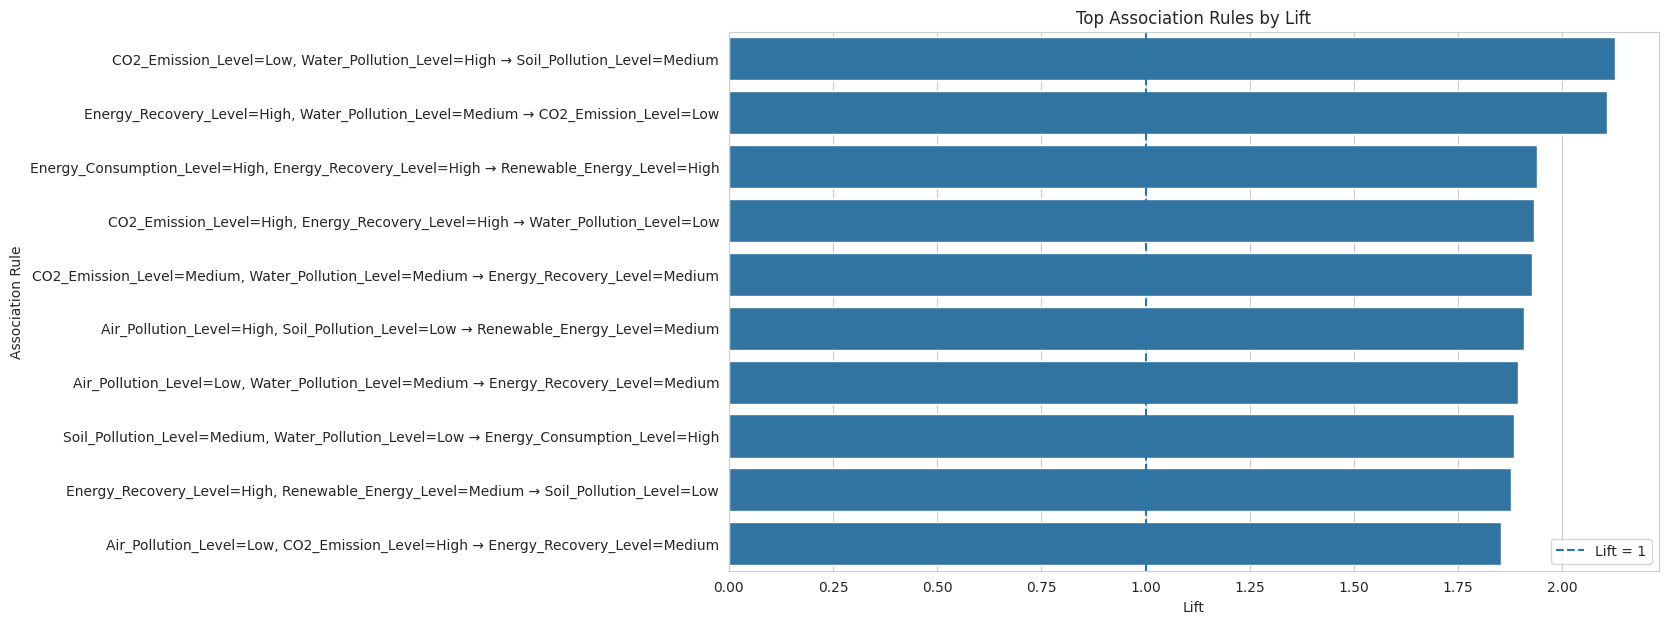

In [ ]:
if len(rules_filtered) > 0:

    plot_data = rules_filtered.head(10).copy()

    plot_data["Rule"] = (
        plot_data["antecedent"] +
        " → " +
        plot_data["consequent"]
    )

    plt.figure(figsize=(12, 7))

    sns.barplot(
        data=plot_data,
        x="lift",
        y="Rule"
    )

    plt.axvline(
        x=1,
        linestyle="--",
        label="Lift = 1"
    )

    plt.title("Top Association Rules by Lift")
    plt.xlabel("Lift")
    plt.ylabel("Association Rule")
    plt.legend()

    plt.show()

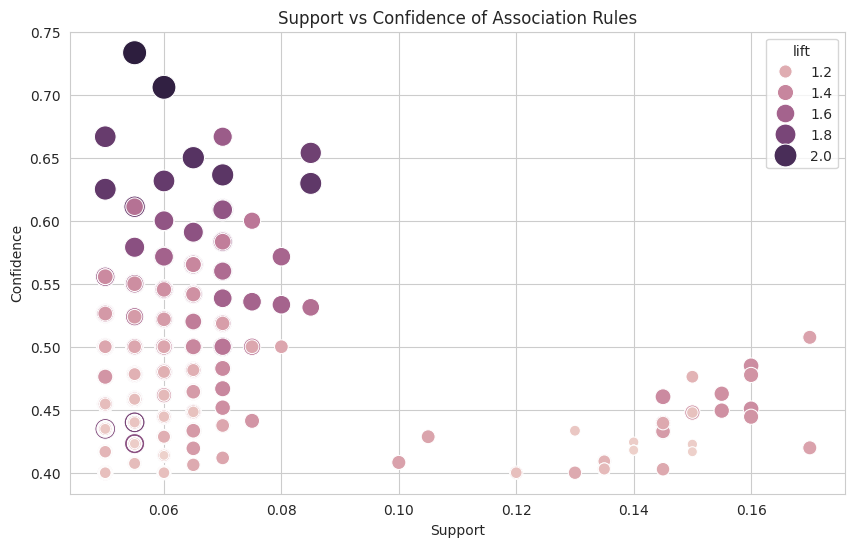

In [ ]:
if len(rules_filtered) > 0:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=rules_filtered,
        x="support",
        y="confidence",
        size="lift",
        hue="lift",
        sizes=(50, 300)
    )

    plt.title("Support vs Confidence of Association Rules")
    plt.xlabel("Support")
    plt.ylabel("Confidence")

    plt.show()

Network nodes: 29
Network edges: 20


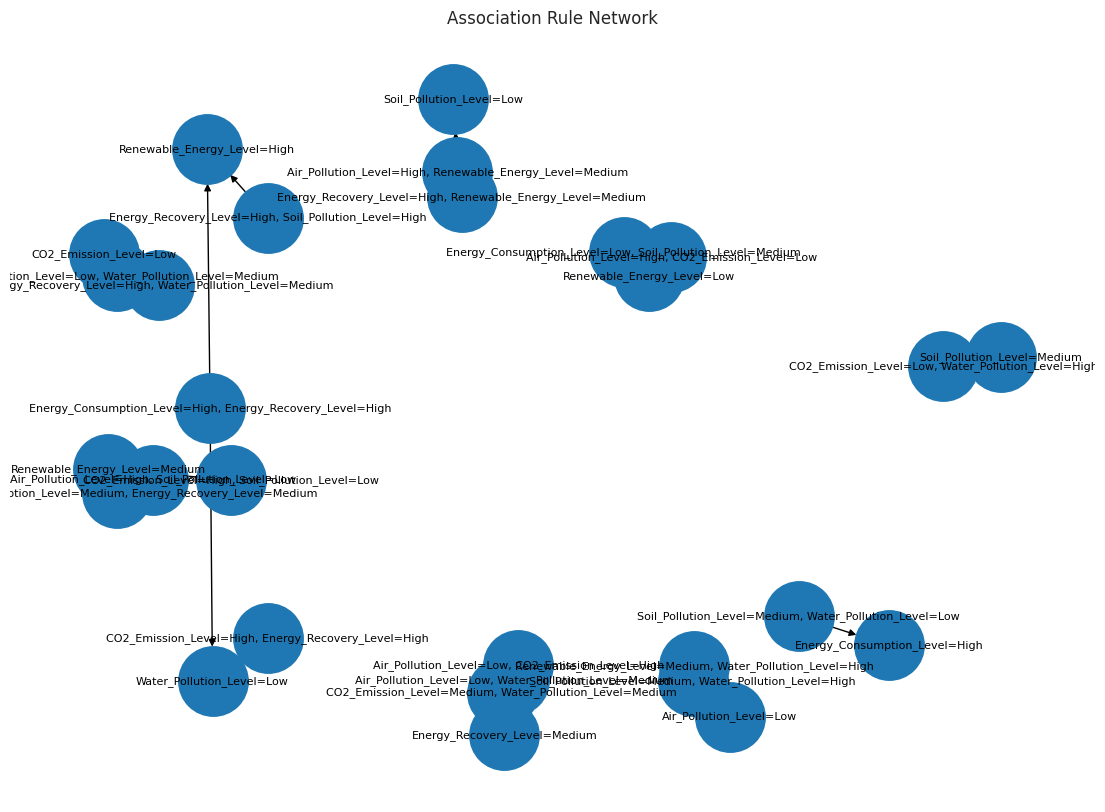

In [ ]:
if len(rules_filtered) > 0:

    G = nx.DiGraph()

    top_network_rules = rules_filtered.head(20)

    for _, row in top_network_rules.iterrows():

        antecedent = row["antecedent"]
        consequent = row["consequent"]

        G.add_edge(
            antecedent,
            consequent,
            weight=row["lift"]
        )

    print("Network nodes:", G.number_of_nodes())
    print("Network edges:", G.number_of_edges())

    plt.figure(figsize=(14, 10))

    pos = nx.spring_layout(
        G,
        seed=42
    )

    nx.draw_networkx(
        G,
        pos,
        with_labels=True,
        node_size=2500,
        font_size=8,
        arrows=True
    )

    plt.title("Association Rule Network")
    plt.axis("off")

    plt.show()

else:

    print("No rules available for network graph.")

In [ ]:
train_transactions, test_transactions = train_test_split(
    transactions,
    test_size=0.30,
    random_state=42
)

print("Training transactions:", len(train_transactions))
print("Testing transactions:", len(test_transactions))

Training transactions: 140
Testing transactions: 60


In [ ]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

transaction_array = np.array(
    transactions,
    dtype=object
)

for fold, (train_index, test_index) in enumerate(
    kf.split(transaction_array),
    start=1
):

    fold_train = [
        transaction_array[i]
        for i in train_index
    ]

    fold_test = [
        transaction_array[i]
        for i in test_index
    ]

    fold_itemsets = apriori(
        fold_train,
        min_support=MIN_SUPPORT
    )

    fold_rules = generate_association_rules(
        fold_itemsets,
        min_confidence=MIN_CONFIDENCE
    )

    fold_rules = fold_rules[
        fold_rules["lift"] > MIN_LIFT
    ]

    if len(fold_rules) > 0:

        avg_lift = fold_rules["lift"].mean()
        rule_count = len(fold_rules)

    else:

        avg_lift = 0
        rule_count = 0

    cv_results.append({
        "Fold": fold,
        "Number_of_Rules": rule_count,
        "Average_Lift": avg_lift
    })

cv_results = pd.DataFrame(cv_results)

cv_results

,Fold,Number_of_Rules,Average_Lift
0,1,582,1.408856
1,2,641,1.451552
2,3,571,1.421034
3,4,614,1.435173
4,5,624,1.445243


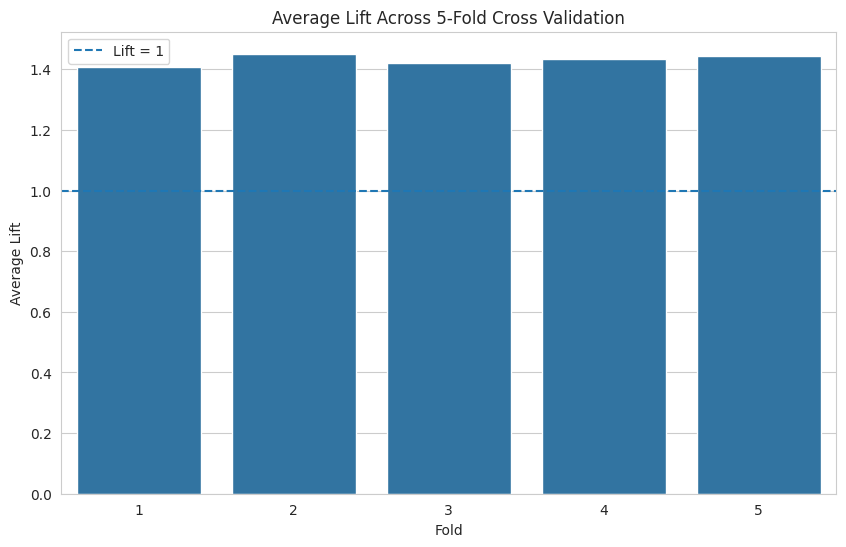

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=cv_results,
    x="Fold",
    y="Average_Lift"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Lift = 1"
)

plt.title("Average Lift Across 5-Fold Cross Validation")
plt.xlabel("Fold")
plt.ylabel("Average Lift")
plt.legend()

plt.show()

In [ ]:
print(
    "Average CV Lift:",
    round(cv_results["Average_Lift"].mean(), 4)
)

print(
    "Total rules across folds:",
    cv_results["Number_of_Rules"].sum()
)

print(
    "Folds containing rules:",
    (cv_results["Number_of_Rules"] > 0).sum(),
    "out of 5"
)

Average CV Lift: 1.4324
Total rules across folds: 3032
Folds containing rules: 5 out of 5


In [ ]:
if len(rules_filtered) > 0:

    print("ACTIONABLE INSIGHTS\n")

    for i, row in rules_filtered.head(5).iterrows():

        print(f"Insight {i+1}:")

        print(
            f"The combination of [{row['antecedent']}] "
            f"is associated with [{row['consequent']}]."
        )

        print(
            f"The rule has confidence of "
            f"{row['confidence']:.2%} and lift of "
            f"{row['lift']:.2f}."
        )

        print(
            "This association can be used as a pattern "
            "for monitoring environmental conditions and "
            "energy-recovery planning."
        )

        print()

else:

    print(
        "No actionable insights can be generated because "
        "no strong association rules were discovered."
    )

ACTIONABLE INSIGHTS

Insight 1:
The combination of [CO2_Emission_Level=Low, Water_Pollution_Level=High] is associated with [Soil_Pollution_Level=Medium].
The rule has confidence of 73.33% and lift of 2.13.
This association can be used as a pattern for monitoring environmental conditions and energy-recovery planning.

Insight 2:
The combination of [Energy_Recovery_Level=High, Water_Pollution_Level=Medium] is associated with [CO2_Emission_Level=Low].
The rule has confidence of 70.59% and lift of 2.11.
This association can be used as a pattern for monitoring environmental conditions and energy-recovery planning.

Insight 3:
The combination of [Energy_Consumption_Level=High, Energy_Recovery_Level=High] is associated with [Renewable_Energy_Level=High].
The rule has confidence of 65.00% and lift of 1.94.
This association can be used as a pattern for monitoring environmental conditions and energy-recovery planning.

Insight 4:
The combination of [CO2_Emission_Level=High, Energy_Recovery_Level

In [ ]:
cv_results.to_csv(
    "cross_validation_results.csv",
    index=False
)

print("cross_validation_results.csv saved.")

cross_validation_results.csv saved.


In [ ]:
df.to_csv(
    "Global_Pollution_Preprocessed.csv",
    index=False
)

print("Preprocessed dataset saved.")

Preprocessed dataset saved.


In [ ]:
print("=" * 60)
print("FINAL PROJECT SUMMARY")
print("=" * 60)

print("\nDataset:")
print("Number of records:", len(df))
print("Number of original features:", 13)

print("\nApriori Parameters:")
print("Minimum Support:", MIN_SUPPORT)
print("Minimum Confidence:", MIN_CONFIDENCE)
print("Minimum Lift:", MIN_LIFT)

print("\nFrequent Itemsets:")
print(len(frequent_itemsets))

print("\nStrong Association Rules:")
print(len(rules_filtered))


print("\nCross Validation:")
print(
    "Average Lift:",
    round(cv_results["Average_Lift"].mean(), 4)
)

print("=" * 60)

FINAL PROJECT SUMMARY

Dataset:
Number of records: 200
Number of original features: 13

Apriori Parameters:
Minimum Support: 0.05
Minimum Confidence: 0.4
Minimum Lift: 1.0

Frequent Itemsets:
404

Strong Association Rules:
516

Cross Validation:
Average Lift: 1.4324


## Conclusion

This project analyzed global pollution and energy-related data using
Exploratory Data Analysis and Apriori Association Rule Mining.

The pollution indicators were transformed into Low, Medium, and High
categories, while energy consumption, energy recovery, renewable energy,
and CO2 emissions were converted into categorical levels.

Apriori Association Rule Mining was applied using a minimum support of
0.05 and minimum confidence of 0.40. Rules with lift greater than 1 were
considered positive associations.

The discovered rules were evaluated using support, confidence, and lift.
The rules were also tested using a train-test split and 5-fold
cross-validation to examine their consistency.

The results provide patterns that can be used to identify combinations
of pollution and energy-related conditions. These associations can support
environmental monitoring, energy-recovery planning, and identification of
conditions that frequently occur together.

It is important to note that association rules identify relationships
between variables and do not establish cause-and-effect relationships.